In [9]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-image'])
    from skimage.metrics import structural_similarity as ssim

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [10]:
from google.colab import drive
drive.mount('/content/drive')


DRIVE_DATASET_PATH = '/content/drive/MyDrive/STL-10 dataset'


VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}
all_image_paths = []
for root, dirs, files in os.walk(DRIVE_DATASET_PATH):
    for fname in sorted(files):
        if os.path.splitext(fname)[1].lower() in VALID_EXT:
            all_image_paths.append(os.path.join(root, fname))

print(f'Total image files found: {len(all_image_paths)}')
if len(all_image_paths) == 0:
    raise FileNotFoundError(f'No images found under: {DRIVE_DATASET_PATH}\n'
                            'Check that the folder name matches exactly.')
print('Sample paths:')
for p in all_image_paths[:3]:
    print(' ', p)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total image files found: 171
Sample paths:
  /content/drive/MyDrive/STL-10 dataset/test_image_png_352.png
  /content/drive/MyDrive/STL-10 dataset/test_image_png_353.png
  /content/drive/MyDrive/STL-10 dataset/test_image_png_354.png


In [11]:
NUM_IMAGES = 100
IMG_SIZE   = (64, 64)

def load_image(path, size=IMG_SIZE):

    try:
        img = Image.open(path).convert('L').resize(size, Image.BILINEAR)
        return np.array(img, dtype=np.float32) / 255.0
    except Exception as e:
        print(f'  Skipping {os.path.basename(path)}: {e}')
        return None

random.shuffle(all_image_paths)

images = []
print(f'Loading {NUM_IMAGES} images ', end='')
for path in all_image_paths:
    if len(images) >= NUM_IMAGES:
        break
    img = load_image(path)
    if img is not None:
        images.append(img)
        print('.', end='', flush=True)

if len(images) < NUM_IMAGES:
    raise RuntimeError(f'Only {len(images)} valid images loaded, need {NUM_IMAGES}.')

images = np.stack(images)  # shape: (100, 64, 64)
print(f'\nDataset ready — shape: {images.shape}')

Loading 100 images ....................................................................................................
Dataset ready — shape: (100, 64, 64)


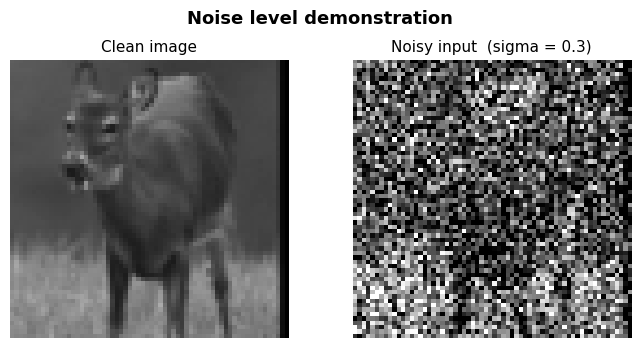

In [12]:
NOISE_STD = 0.3  # Gaussian noise std on [0,1] scale

def add_gaussian_noise(imgs, std=NOISE_STD):

    noise = np.random.normal(0.0, std, size=imgs.shape).astype(np.float32)
    return np.clip(imgs + noise, 0.0, 1.0)

sample_clean = images[0]
sample_noisy = add_gaussian_noise(sample_clean[np.newaxis])[0]

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(sample_clean, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Clean image', fontsize=11); axes[0].axis('off')
axes[1].imshow(sample_noisy, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Noisy input  (sigma = {NOISE_STD})', fontsize=11); axes[1].axis('off')
fig.suptitle('Noise level demonstration', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
idx = list(range(NUM_IMAGES))
random.shuffle(idx)
train_images = images[idx[:80]]   # (80, 64, 64)
test_images  = images[idx[80:]]   # (20, 64, 64)
print(f'Train: {len(train_images)}   Test: {len(test_images)}')


class NoisyImageDataset(Dataset):

    def __init__(self, clean_imgs, noise_std=NOISE_STD):
        self.clean = clean_imgs
        self.noise_std = noise_std

    def __len__(self):
        return len(self.clean)

    def __getitem__(self, idx):
        clean = self.clean[idx]
        noise = np.random.normal(0, self.noise_std, clean.shape).astype(np.float32)
        noisy = np.clip(clean + noise, 0.0, 1.0)
        return torch.from_numpy(noisy[np.newaxis]), torch.from_numpy(clean[np.newaxis])


train_loader = DataLoader(NoisyImageDataset(train_images), batch_size=16, shuffle=True,  num_workers=2)
test_loader  = DataLoader(NoisyImageDataset(test_images),  batch_size=20, shuffle=False, num_workers=2)

Train: 80   Test: 20


In [14]:
class DenoisingAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1,   32,  3, stride=2, padding=1), nn.BatchNorm2d(32),  nn.LeakyReLU(0.1),
            nn.Conv2d(32,  64,  3, stride=2, padding=1), nn.BatchNorm2d(64),  nn.LeakyReLU(0.1),
            nn.Conv2d(64,  128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.1),
            nn.Conv2d(128, 8,   1),                      nn.BatchNorm2d(8),   nn.LeakyReLU(0.1),
        )


        self.decoder = nn.Sequential(
            nn.Conv2d(8, 128, 1),                                  nn.BatchNorm2d(128), nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  nn.BatchNorm2d(64),  nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(64,  32, 4, stride=2, padding=1),  nn.BatchNorm2d(32),  nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(32,   1, 4, stride=2, padding=1),  nn.Sigmoid(),  # output in [0,1]
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = DenoisingAutoencoder().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {n_params:,}')

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.1)
    (9): Conv2d(128, 8, kernel_size=(1, 1), stride=(1, 1))
    (10): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.1)
  )
  (decoder): Sequential(
    (0): Conv2d(8, 128, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, tra

In [15]:
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

history = {'epoch': [], 'train_mse': [], 'test_mse': []}


def evaluate(loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for noisy, clean in loader:
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
            total += criterion(model(noisy), clean).item()
    return total / len(loader)


print(f'Training for {NUM_EPOCHS} epochs on {DEVICE} ...')
print('-' * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running = 0.0
    for noisy, clean in train_loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(noisy), clean)
        loss.backward()
        optimizer.step()
        running += loss.item()

    train_mse = running / len(train_loader)
    test_mse  = evaluate(test_loader)
    scheduler.step()

    history['epoch'].append(epoch)
    history['train_mse'].append(train_mse)
    history['test_mse'].append(test_mse)


    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch [{epoch:>3}/{NUM_EPOCHS}]  Train MSE: {train_mse:.5f}   Test MSE: {test_mse:.5f}')

print('-' * 56)
print('Training complete.')

Training for 100 epochs on cuda ...
--------------------------------------------------------
Epoch [  1/100]  Train MSE: 0.07133   Test MSE: 0.05835
Epoch [ 10/100]  Train MSE: 0.01263   Test MSE: 0.01090
Epoch [ 20/100]  Train MSE: 0.01062   Test MSE: 0.00902
Epoch [ 30/100]  Train MSE: 0.00943   Test MSE: 0.00819
Epoch [ 40/100]  Train MSE: 0.00859   Test MSE: 0.00770
Epoch [ 50/100]  Train MSE: 0.00873   Test MSE: 0.00760
Epoch [ 60/100]  Train MSE: 0.00860   Test MSE: 0.00743
Epoch [ 70/100]  Train MSE: 0.00848   Test MSE: 0.00725
Epoch [ 80/100]  Train MSE: 0.00794   Test MSE: 0.00725
Epoch [ 90/100]  Train MSE: 0.00880   Test MSE: 0.00727
Epoch [100/100]  Train MSE: 0.00797   Test MSE: 0.00731
--------------------------------------------------------
Training complete.


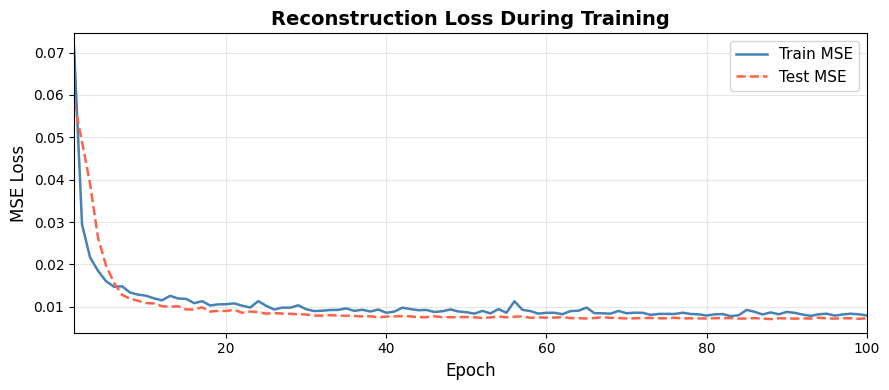

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history['epoch'], history['train_mse'], label='Train MSE', color='steelblue', linewidth=1.8)
ax.plot(history['epoch'], history['test_mse'],  label='Test MSE',  color='tomato',    linewidth=1.8, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Reconstruction Loss During Training', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, NUM_EPOCHS)
plt.tight_layout(); plt.show()

In [17]:
def compute_metrics(clean_imgs):

    model.eval()
    noisy_np = add_gaussian_noise(clean_imgs)
    noisy_t  = torch.from_numpy(noisy_np[:, np.newaxis]).to(DEVICE)
    with torch.no_grad():
        recon_np = model(noisy_t).squeeze(1).cpu().numpy()

    mse_list, ssim_list = [], []
    for i in range(len(clean_imgs)):
        mse_list.append(float(np.mean((recon_np[i] - clean_imgs[i])**2)))
        ssim_list.append(float(ssim(clean_imgs[i], recon_np[i], data_range=1.0)))

    return dict(mean_mse=float(np.mean(mse_list)),   std_mse=float(np.std(mse_list)),
                mean_ssim=float(np.mean(ssim_list)), std_ssim=float(np.std(ssim_list)),
                mse_list=mse_list, noisy_np=noisy_np, recon_np=recon_np)


train_metrics = compute_metrics(train_images)
test_metrics  = compute_metrics(test_images)

table = pd.DataFrame({
    'Split':     ['Train (80 images)', 'Test (20 images)'],
    'Mean MSE':  [f"{train_metrics['mean_mse']:.5f}",  f"{test_metrics['mean_mse']:.5f}"],
    'Std MSE':   [f"{train_metrics['std_mse']:.5f}",   f"{test_metrics['std_mse']:.5f}"],
    'Mean SSIM': [f"{train_metrics['mean_ssim']:.4f}", f"{test_metrics['mean_ssim']:.4f}"],
    'Std SSIM':  [f"{train_metrics['std_ssim']:.4f}",  f"{test_metrics['std_ssim']:.4f}"],
}).set_index('Split')

print('=== Reconstruction Metrics ===')
print(table.to_string())
table

=== Reconstruction Metrics ===
                  Mean MSE  Std MSE Mean SSIM Std SSIM
Split                                                 
Train (80 images)  0.00740  0.00266    0.5703   0.0691
Test (20 images)   0.00713  0.00233    0.5846   0.0556


,Mean MSE,Std MSE,Mean SSIM,Std SSIM
Split,,,,
Train (80 images),0.00740,0.00266,0.5703,0.0691
Test (20 images),0.00713,0.00233,0.5846,0.0556


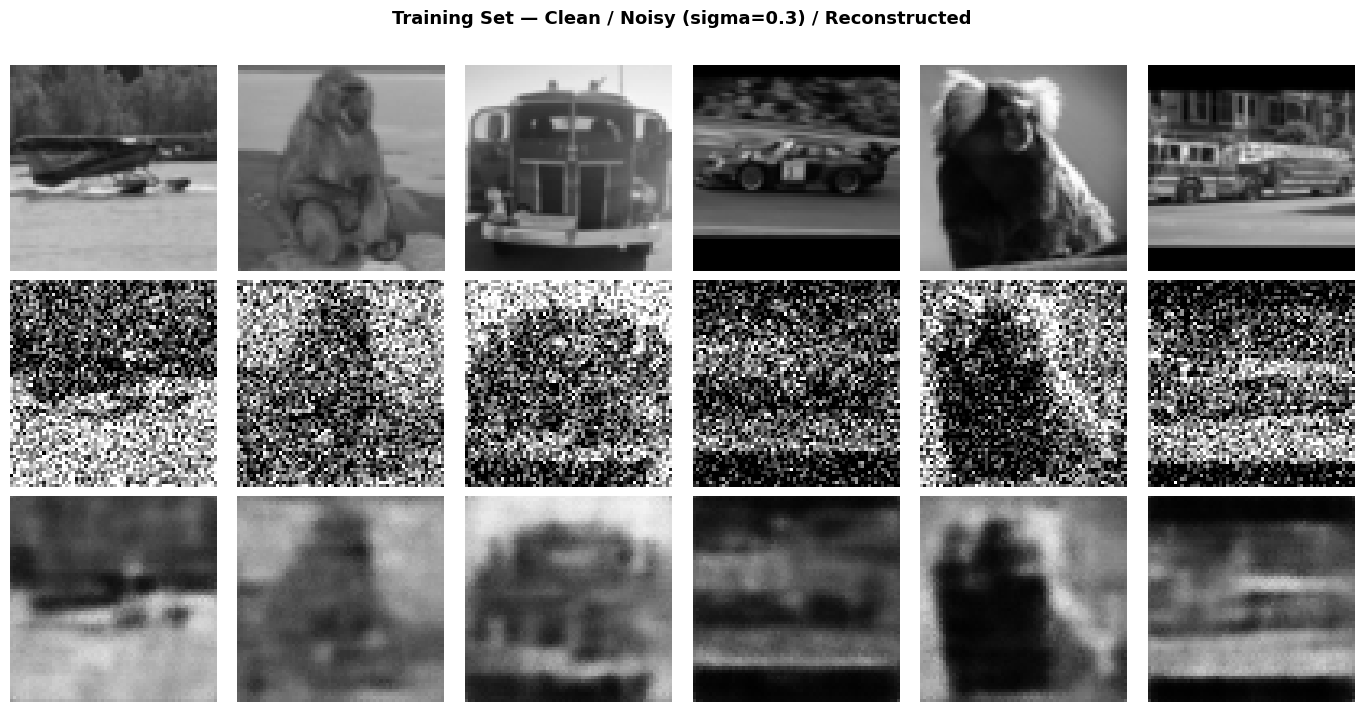

In [18]:
def show_triplets(clean_imgs, noisy_imgs, recon_imgs, title, n=6):
    n = min(n, len(clean_imgs))
    fig, axes = plt.subplots(3, n, figsize=(2.3*n, 7))
    row_labels = ['Clean (target)', 'Noisy (input)', 'Reconstructed']
    for col in range(n):
        for row, (img, lbl) in enumerate(zip(
                [clean_imgs[col], noisy_imgs[col], recon_imgs[col]], row_labels)):
            ax = axes[row, col]
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(lbl, fontsize=10, rotation=0, labelpad=95, va='center')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


show_triplets(train_images, train_metrics['noisy_np'], train_metrics['recon_np'],
              title=f'Training Set — Clean / Noisy (sigma={NOISE_STD}) / Reconstructed', n=6)

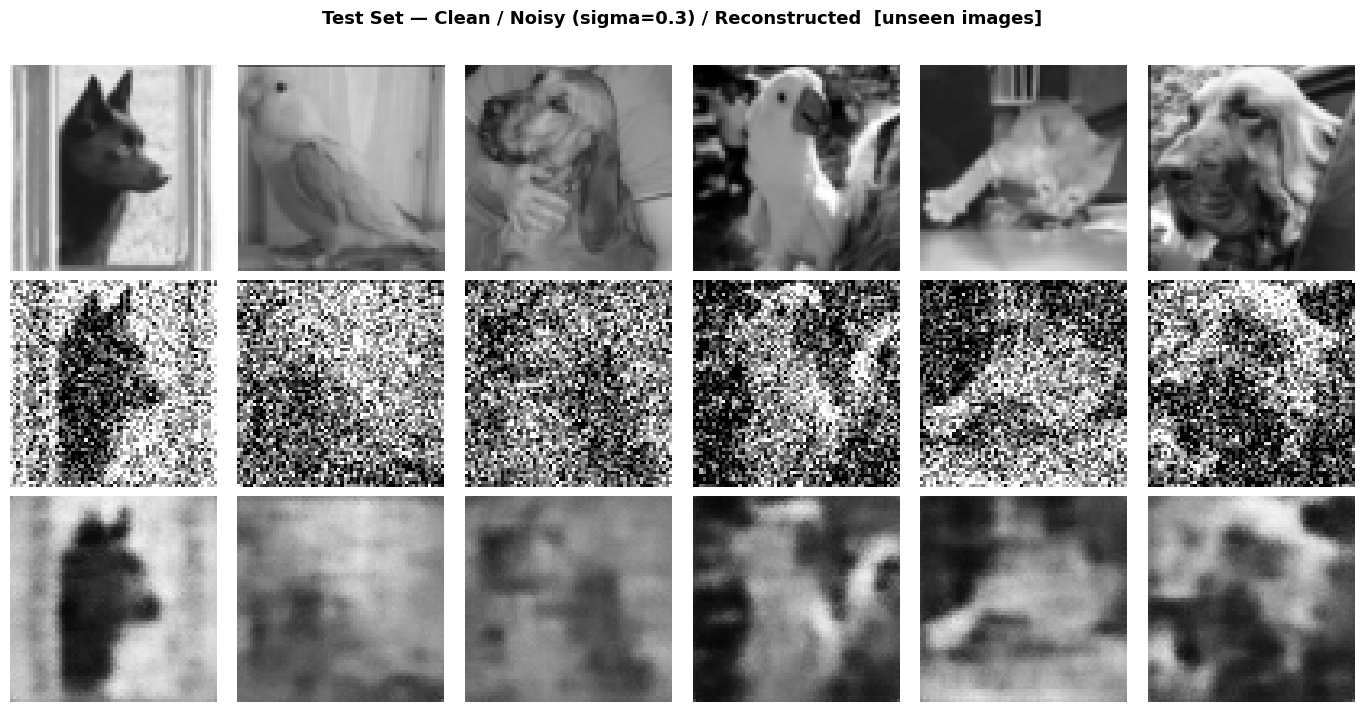

In [19]:
show_triplets(test_images, test_metrics['noisy_np'], test_metrics['recon_np'],
              title=f'Test Set — Clean / Noisy (sigma={NOISE_STD}) / Reconstructed  [unseen images]', n=6)

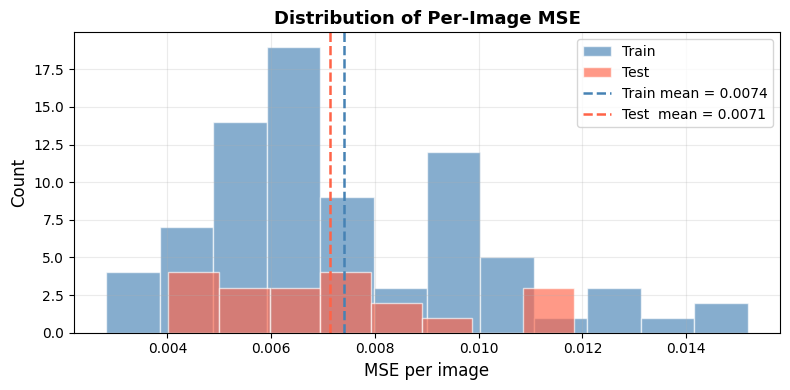

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_metrics['mse_list'], bins=12, alpha=0.65, color='steelblue', label='Train', edgecolor='white')
ax.hist(test_metrics['mse_list'],  bins=8,  alpha=0.65, color='tomato',    label='Test',  edgecolor='white')
ax.axvline(train_metrics['mean_mse'], color='steelblue', linestyle='--', linewidth=1.8,
           label=f"Train mean = {train_metrics['mean_mse']:.4f}")
ax.axvline(test_metrics['mean_mse'],  color='tomato',    linestyle='--', linewidth=1.8,
           label=f"Test  mean = {test_metrics['mean_mse']:.4f}")
ax.set_xlabel('MSE per image', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Per-Image MSE', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()